## 1. Setup y Configuración

In [19]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
from datetime import datetime
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

# Sklearn
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Check GPU
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✓ GPU detectada: {gpus[0].name}")
    # Permitir crecimiento de memoria
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠️ No se detectó GPU, usando CPU")

# Path setup
BASE_DIR = Path.cwd().parents[1]
sys.path.append(str(BASE_DIR / 'src'))

from config import PROCESSED_DIR, logger

# Configuración
TARGET_COMMODITIES = ['Corn', 'Soybeans', 'Wheat']
HORIZONS = {'t5': 5, 't21': 21}  # Saltamos t1 (random)
RANDOM_STATE = 42
FINAL_DIR = PROCESSED_DIR / 'final_modeling'

# Reproducibilidad
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(f"\n✓ Base directory: {BASE_DIR}")
print(f"✓ Commodities: {TARGET_COMMODITIES}")
print(f"✓ Horizontes: {list(HORIZONS.keys())}")

TensorFlow version: 2.18.0
⚠️ No se detectó GPU, usando CPU

✓ Base directory: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal
✓ Commodities: ['Corn', 'Soybeans', 'Wheat']
✓ Horizontes: ['t5', 't21']


## 2. Carga de Datos

In [20]:
# Cargar features seleccionadas
with open(FINAL_DIR / 'selected_features.json', 'r') as f:
    selected_features = json.load(f)
print("✓ Features seleccionadas cargadas")

# Cargar resultados baseline de 4.2 para comparación
df_baseline = pd.read_csv(FINAL_DIR / 'logit_lasso_results_summary.csv')
print("\n📊 BASELINE (Logit-LASSO) para comparación:")
display(df_baseline[['Commodity', 'Horizon', 'Test_AUC', 'Test_F1']].round(4))

# Cargar dataset
df = pd.read_csv(PROCESSED_DIR / 'features_final_modeling.csv', parse_dates=['date'])
n_before = len(df)
df = df.drop_duplicates(subset=['date'], keep='first').reset_index(drop=True)
df = df.sort_values('date').reset_index(drop=True)
print(f"\n✓ Dataset: {n_before:,} → {len(df):,} filas")
print(f"  Rango: {df['date'].min().date()} a {df['date'].max().date()}")

# Crear targets
for commodity in TARGET_COMMODITIES:
    for h_name, h_days in HORIZONS.items():
        target_col = f'{commodity}_direction_{h_name}'
        if target_col not in df.columns:
            future_price = df[commodity].shift(-h_days)
            df[target_col] = (future_price > df[commodity]).astype(float)

print("✓ Targets creados")

✓ Features seleccionadas cargadas

📊 BASELINE (Logit-LASSO) para comparación:


,Commodity,Horizon,Test_AUC,Test_F1
0,Corn,t1,0.4878,0.5369
1,Corn,t5,0.5322,0.6288
2,Corn,t21,0.6416,0.6208
3,Soybeans,t1,0.5000,0.0000
4,Soybeans,t5,0.4637,0.0272
5,Soybeans,t21,0.5870,0.5984
6,Wheat,t1,0.4902,0.6359
7,Wheat,t5,0.5376,0.6236
8,Wheat,t21,0.5503,0.4345


KeyboardInterrupt: 

## 3. Preparación de Secuencias para LSTM

LSTM requiere datos en formato 3D: `(samples, timesteps, features)`

In [ ]:
def create_sequences(X, y, sequence_length):
    """
    Crea secuencias para LSTM.
    
    Args:
        X: Features array (n_samples, n_features)
        y: Target array (n_samples,)
        sequence_length: Número de timesteps
    
    Returns:
        X_seq: (n_sequences, sequence_length, n_features)
        y_seq: (n_sequences,)
    """
    X_seq, y_seq = [], []
    
    for i in range(len(X) - sequence_length):
        X_seq.append(X[i:i + sequence_length])
        y_seq.append(y[i + sequence_length])
    
    return np.array(X_seq), np.array(y_seq)


def prepare_lstm_data(df, commodity, horizon_name, feature_list, 
                      sequence_length=21, split_date='2023-01-01'):
    """
    Prepara datos para LSTM con split temporal.
    
    Literatura recomienda:
    - sequence_length=21 (1 mes de trading)
    - Split temporal (no aleatorio) para series de tiempo
    """
    target_col = f'{commodity}_direction_{horizon_name}'
    feature_cols = [f for f in feature_list if f in df.columns]
    
    # Preparar features y target
    df_work = df[['date'] + feature_cols + [target_col]].copy()
    df_work = df_work.dropna(subset=[target_col])
    
    # Limpiar NaN/Inf en features
    for col in feature_cols:
        df_work[col] = df_work[col].replace([np.inf, -np.inf], np.nan)
        df_work[col] = df_work[col].fillna(df_work[col].median())
    
    # Split temporal
    train_data = df_work[df_work['date'] < split_date].copy()
    test_data = df_work[df_work['date'] >= split_date].copy()
    
    # Escalar features (fit solo en train)
    scaler = StandardScaler()
    X_train_raw = scaler.fit_transform(train_data[feature_cols])
    X_test_raw = scaler.transform(test_data[feature_cols])
    
    y_train_raw = train_data[target_col].values
    y_test_raw = test_data[target_col].values
    
    # Crear secuencias
    X_train, y_train = create_sequences(X_train_raw, y_train_raw, sequence_length)
    X_test, y_test = create_sequences(X_test_raw, y_test_raw, sequence_length)
    
    print(f"  Train: {X_train.shape[0]:,} secuencias | Test: {X_test.shape[0]:,} secuencias")
    print(f"  Shape: ({X_train.shape[1]} timesteps, {X_train.shape[2]} features)")
    
    return X_train, X_test, y_train, y_test, feature_cols, scaler

print("✓ Funciones de preparación de datos definidas")

✓ Funciones de preparación de datos definidas


## 4. Arquitectura LSTM

Basada en mejores prácticas de literatura:
- **2 capas LSTM** con dropout entre ellas
- **BatchNormalization** para estabilizar entrenamiento
- **Dropout 0.3** para regularización
- **Dense final** con sigmoid para clasificación binaria

In [ ]:
def build_lstm_classifier(sequence_length, n_features, 
                          lstm_units_1=64, lstm_units_2=32,
                          dropout_rate=0.3, learning_rate=0.001):
    """
    Construye modelo LSTM para clasificación binaria.
    
    Arquitectura basada en:
    - Nature Sci. Reports (2025): 128 units, dropout
    - PMC BiLSTM (2024): 2 layers, 25-26 neurons
    - ASTESJ (2021): 4 LSTM layers con dropout
    """
    model = Sequential([
        # Input
        Input(shape=(sequence_length, n_features)),
        
        # Primera capa LSTM - return_sequences=True para stacking
        LSTM(lstm_units_1, return_sequences=True, 
             kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        # Segunda capa LSTM
        LSTM(lstm_units_2, return_sequences=False,
             kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        # Capa densa intermedia
        Dense(16, activation='relu'),
        Dropout(dropout_rate / 2),
        
        # Output - Clasificación binaria
        Dense(1, activation='sigmoid')
    ])
    
    # Compilar
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    return model


# Visualizar arquitectura ejemplo
example_model = build_lstm_classifier(21, 50)
example_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 21, 64)         │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 21, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,785 (167.13 KB)

 Trainable params: 42,593 (166.38 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Callbacks para entrenamiento
def get_callbacks(model_name, patience_es=15, patience_lr=5):
    """
    Callbacks según mejores prácticas:
    - EarlyStopping: Previene overfitting
    - ReduceLROnPlateau: Adapta learning rate
    - ModelCheckpoint: Guarda mejor modelo
    """
    callbacks = [
        EarlyStopping(
            monitor='val_auc',
            patience=patience_es,
            restore_best_weights=True,
            mode='max',
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=patience_lr,
            min_lr=1e-6,
            verbose=1
        )
    ]
    return callbacks

print("✓ Callbacks definidos")

✓ Callbacks definidos


## 5. Entrenamiento LSTM

In [ ]:
# =============================================================================
# CONFIGURACIÓN DE HIPERPARÁMETROS (basada en literatura)
# =============================================================================
LSTM_CONFIG = {
    'sequence_length': 21,    # 1 mes de trading (PMC 2024: 24 timesteps)
    'lstm_units_1': 64,       # Primera capa (Nature 2025: 128, ajustamos por dataset)
    'lstm_units_2': 32,       # Segunda capa
    'dropout_rate': 0.3,      # Dropout (ASTESJ 2021: 0.2-0.3)
    'learning_rate': 0.001,   # Learning rate (PMC 2024: 0.001)
    'batch_size': 32,         # Batch size (MDPI 2024: 32)
    'epochs': 150,            # Con early stopping
    'validation_split': 0.15  # 15% para validación
}

print("CONFIGURACIÓN LSTM:")
for k, v in LSTM_CONFIG.items():
    print(f"  {k}: {v}")

CONFIGURACIÓN LSTM:
  sequence_length: 21
  lstm_units_1: 64
  lstm_units_2: 32
  dropout_rate: 0.3
  learning_rate: 0.001
  batch_size: 32
  epochs: 150
  validation_split: 0.15


In [ ]:
# =============================================================================
# ENTRENAR LSTM PARA CADA COMMODITY Y HORIZONTE
# =============================================================================
print("="*80)
print("ENTRENAMIENTO LSTM - Clasificación Direccional")
print("="*80)

lstm_results = {}
lstm_models = {}
lstm_histories = {}

for commodity in TARGET_COMMODITIES:
    print(f"\n{'='*60}")
    print(f"COMMODITY: {commodity}")
    print('='*60)
    
    lstm_results[commodity] = {}
    lstm_models[commodity] = {}
    lstm_histories[commodity] = {}
    
    for horizon_name, horizon_days in HORIZONS.items():
        print(f"\n[{horizon_name}] Preparando datos...")
        start_time = time.time()
        
        # Obtener features seleccionadas
        feature_list = selected_features[commodity][horizon_name]
        
        # Preparar datos
        X_train, X_test, y_train, y_test, feature_names, scaler = prepare_lstm_data(
            df, commodity, horizon_name, feature_list,
            sequence_length=LSTM_CONFIG['sequence_length']
        )
        
        # Verificar balance de clases
        train_balance = y_train.mean()
        test_balance = y_test.mean()
        print(f"  Balance train: {train_balance:.2%} positivos | test: {test_balance:.2%}")
        
        # Calcular class weights para desbalance
        n_pos = y_train.sum()
        n_neg = len(y_train) - n_pos
        class_weight = {0: len(y_train) / (2 * n_neg), 1: len(y_train) / (2 * n_pos)}
        
        # Construir modelo
        print(f"[{horizon_name}] Construyendo modelo...")
        model = build_lstm_classifier(
            sequence_length=LSTM_CONFIG['sequence_length'],
            n_features=X_train.shape[2],
            lstm_units_1=LSTM_CONFIG['lstm_units_1'],
            lstm_units_2=LSTM_CONFIG['lstm_units_2'],
            dropout_rate=LSTM_CONFIG['dropout_rate'],
            learning_rate=LSTM_CONFIG['learning_rate']
        )
        
        # Callbacks
        callbacks = get_callbacks(f"{commodity}_{horizon_name}")
        
        # Entrenar
        print(f"[{horizon_name}] Entrenando...")
        history = model.fit(
            X_train, y_train,
            validation_split=LSTM_CONFIG['validation_split'],
            epochs=LSTM_CONFIG['epochs'],
            batch_size=LSTM_CONFIG['batch_size'],
            class_weight=class_weight,
            callbacks=callbacks,
            verbose=0
        )
        
        # Evaluar en test
        y_prob = model.predict(X_test, verbose=0).flatten()
        y_pred = (y_prob >= 0.5).astype(int)
        
        # Métricas
        test_metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_prob),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0)
        }
        
        # Obtener baseline para comparación
        baseline_row = df_baseline[
            (df_baseline['Commodity'] == commodity) & 
            (df_baseline['Horizon'] == horizon_name)
        ]
        baseline_auc = baseline_row['Test_AUC'].values[0] if len(baseline_row) > 0 else 0
        
        elapsed = time.time() - start_time
        
        # Guardar resultados
        lstm_results[commodity][horizon_name] = {
            'test_metrics': test_metrics,
            'baseline_auc': baseline_auc,
            'delta_auc': test_metrics['roc_auc'] - baseline_auc,
            'epochs_trained': len(history.history['loss']),
            'n_features': X_train.shape[2],
            'y_test': y_test,
            'y_prob': y_prob,
            'y_pred': y_pred
        }
        lstm_models[commodity][horizon_name] = model
        lstm_histories[commodity][horizon_name] = history.history
        
        # Imprimir resultados
        delta = test_metrics['roc_auc'] - baseline_auc
        print(f"\n[{horizon_name}] RESULTADOS:")
        print(f"    Epochs: {len(history.history['loss'])} | Tiempo: {elapsed:.1f}s")
        print(f"    AUC: {test_metrics['roc_auc']:.4f} (baseline: {baseline_auc:.4f}, Δ={delta:+.4f})")
        print(f"    Accuracy: {test_metrics['accuracy']:.4f} | F1: {test_metrics['f1']:.4f}")

ENTRENAMIENTO LSTM - Clasificación Direccional

COMMODITY: Corn

[t5] Preparando datos...
  Train: 5,966 secuencias | Test: 723 secuencias
  Shape: (21 timesteps, 110 features)
  Balance train: 50.28% positivos | test: 48.55%
[t5] Construyendo modelo...
[t5] Entrenando...

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 9.
Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 9.

[t5] RESULTADOS:
    Epochs: 24 | Tiempo: 28.5s
    AUC: 0.5319 (baseline: 0.5322, Δ=-0.0003)
    Accuracy: 0.5035 | F1: 0.3364

[t21] Preparando datos...
  Train: 5,966 secuencias | Test: 723 secuencias
  Shape: (21 timesteps, 108 features)
  Ba

## 6. Visualización de Entrenamiento

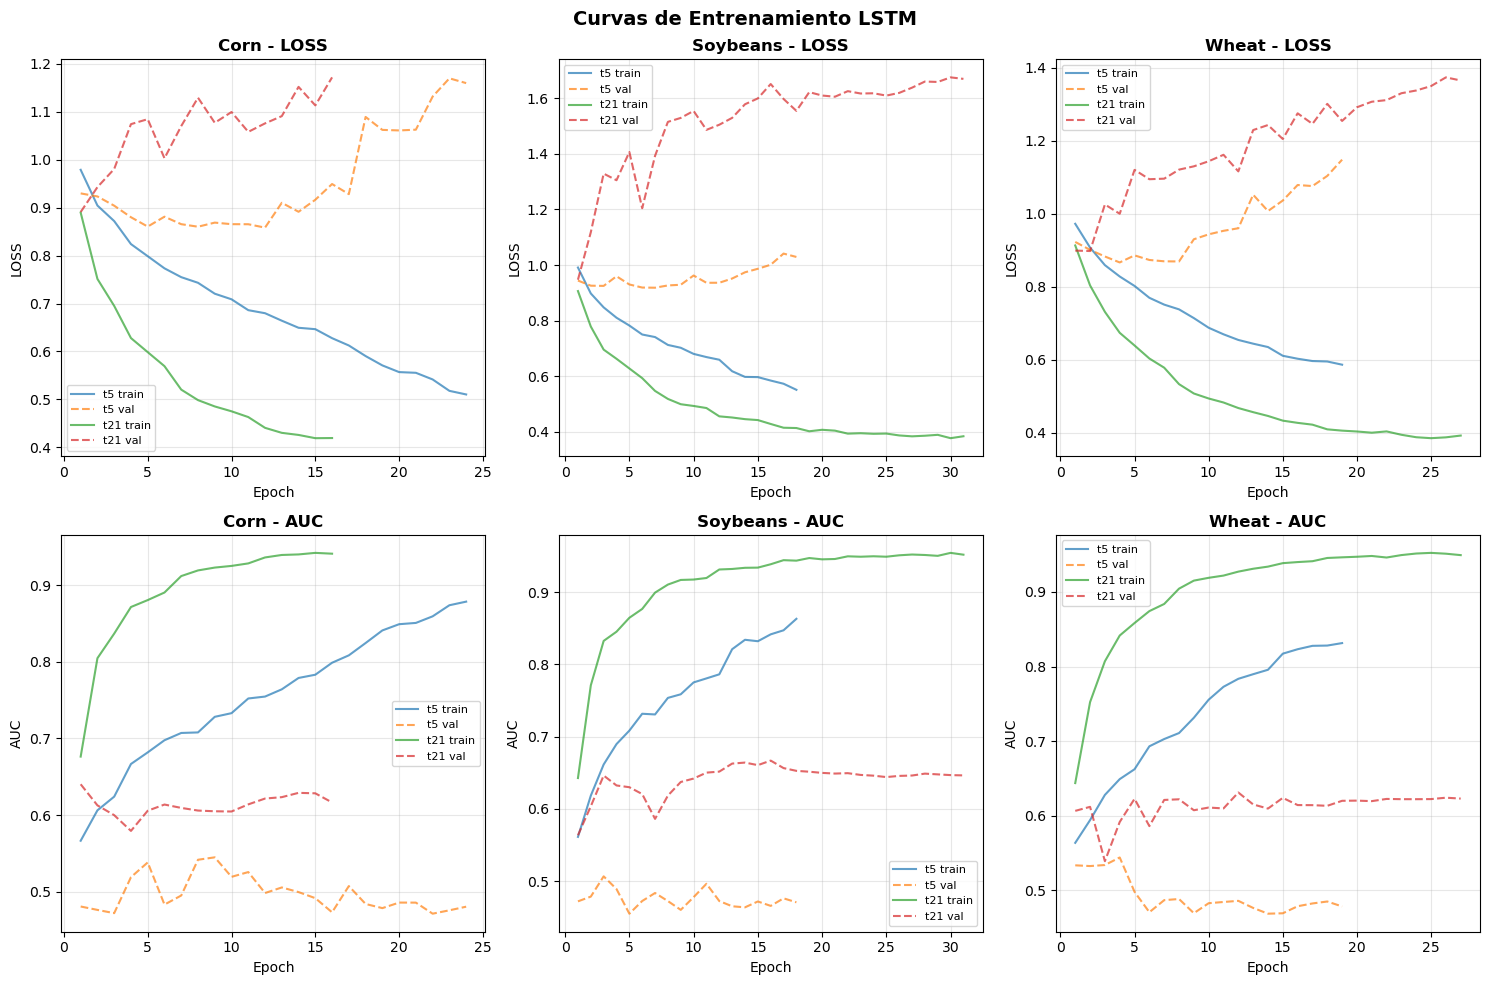

In [ ]:
# Curvas de entrenamiento
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, commodity in enumerate(TARGET_COMMODITIES):
    for row, metric in enumerate(['loss', 'auc']):
        ax = axes[row, idx]
        
        for horizon_name in HORIZONS.keys():
            history = lstm_histories[commodity][horizon_name]
            epochs = range(1, len(history[metric]) + 1)
            
            ax.plot(epochs, history[metric], '-', label=f'{horizon_name} train', alpha=0.7)
            ax.plot(epochs, history[f'val_{metric}'], '--', label=f'{horizon_name} val', alpha=0.7)
        
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.upper())
        ax.set_title(f'{commodity} - {metric.upper()}', fontsize=12, fontweight='bold')
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de Entrenamiento LSTM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Comparación LSTM vs Logit-LASSO

In [ ]:
# Tabla comparativa
comparison_rows = []

for commodity in TARGET_COMMODITIES:
    for horizon_name in HORIZONS.keys():
        lstm_res = lstm_results[commodity][horizon_name]
        
        comparison_rows.append({
            'Commodity': commodity,
            'Horizon': horizon_name,
            'LASSO_AUC': lstm_res['baseline_auc'],
            'LSTM_AUC': lstm_res['test_metrics']['roc_auc'],
            'Δ_AUC': lstm_res['delta_auc'],
            'LSTM_Accuracy': lstm_res['test_metrics']['accuracy'],
            'LSTM_F1': lstm_res['test_metrics']['f1'],
            'LSTM_Precision': lstm_res['test_metrics']['precision'],
            'LSTM_Recall': lstm_res['test_metrics']['recall'],
            'Epochs': lstm_res['epochs_trained']
        })

df_comparison = pd.DataFrame(comparison_rows)
print("="*100)
print("COMPARACIÓN: LOGIT-LASSO vs LSTM")
print("="*100)
display(df_comparison.round(4))

# Resumen
print("\n" + "="*60)
print("RESUMEN")
print("="*60)
avg_delta = df_comparison['Δ_AUC'].mean()
wins = (df_comparison['Δ_AUC'] > 0).sum()
total = len(df_comparison)

print(f"\nΔ AUC promedio (LSTM vs LASSO): {avg_delta:+.4f}")
print(f"LSTM gana en {wins}/{total} casos ({wins/total:.0%})")

print(f"\nMejor LSTM: {df_comparison.loc[df_comparison['LSTM_AUC'].idxmax(), 'Commodity']} "
      f"{df_comparison.loc[df_comparison['LSTM_AUC'].idxmax(), 'Horizon']} "
      f"(AUC={df_comparison['LSTM_AUC'].max():.4f})")

COMPARACIÓN: LOGIT-LASSO vs LSTM


,Commodity,Horizon,LASSO_AUC,LSTM_AUC,Δ_AUC,LSTM_Accuracy,LSTM_F1,LSTM_Precision,LSTM_Recall,Epochs
0,Corn,t5,0.5322,0.5319,-0.0003,0.5035,0.3364,0.4789,0.2593,24
1,Corn,t21,0.6416,0.6673,0.0257,0.4440,0.6059,0.4346,1.0000,16
2,Soybeans,t5,0.4637,0.5128,0.0492,0.5007,0.2101,0.4000,0.1424,18
3,Soybeans,t21,0.5870,0.5702,-0.0168,0.5961,0.0000,0.0000,0.0000,31
4,Wheat,t5,0.5376,0.4893,-0.0484,0.4882,0.2449,0.4027,0.1760,19
5,Wheat,t21,0.5503,0.6064,0.0561,0.5934,0.5051,0.4870,0.5245,27



RESUMEN

Δ AUC promedio (LSTM vs LASSO): +0.0109
LSTM gana en 3/6 casos (50%)

Mejor LSTM: Corn t21 (AUC=0.6673)


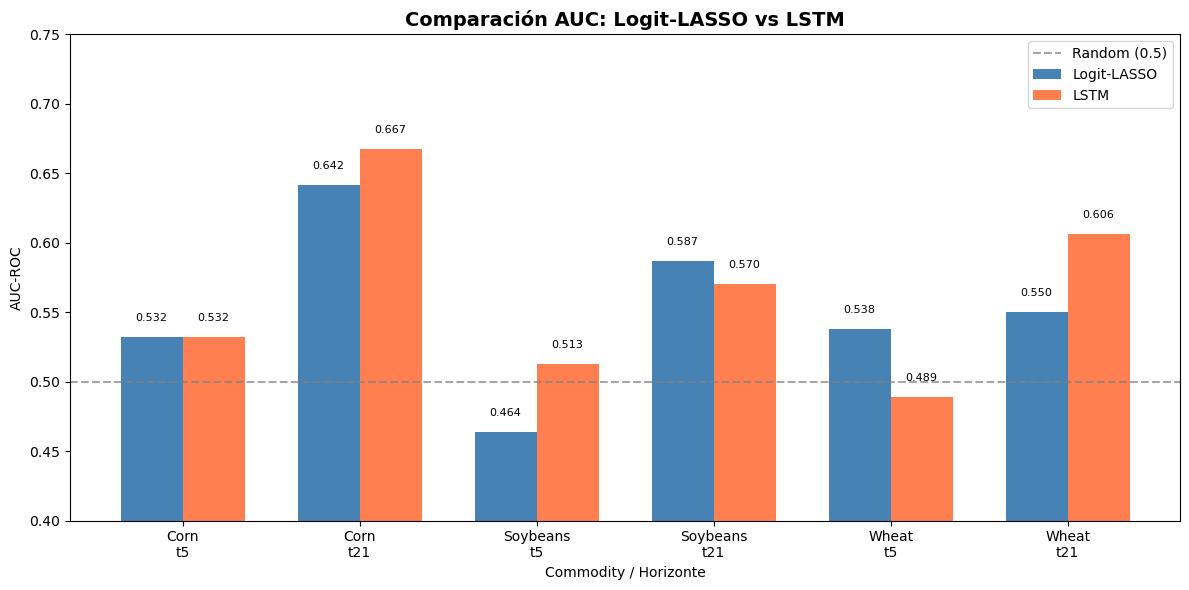

In [ ]:
# Visualización comparativa
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_comparison))
width = 0.35

bars1 = ax.bar(x - width/2, df_comparison['LASSO_AUC'], width, label='Logit-LASSO', color='steelblue')
bars2 = ax.bar(x + width/2, df_comparison['LSTM_AUC'], width, label='LSTM', color='coral')

ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Random (0.5)')

ax.set_xlabel('Commodity / Horizonte')
ax.set_ylabel('AUC-ROC')
ax.set_title('Comparación AUC: Logit-LASSO vs LSTM', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"{row['Commodity']}\n{row['Horizon']}" for _, row in df_comparison.iterrows()])
ax.legend()
ax.set_ylim([0.4, 0.75])

# Agregar valores
for bar, val in zip(bars1, df_comparison['LASSO_AUC']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', 
            ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars2, df_comparison['LSTM_AUC']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', 
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'lstm_vs_lasso_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Matrices de Confusión

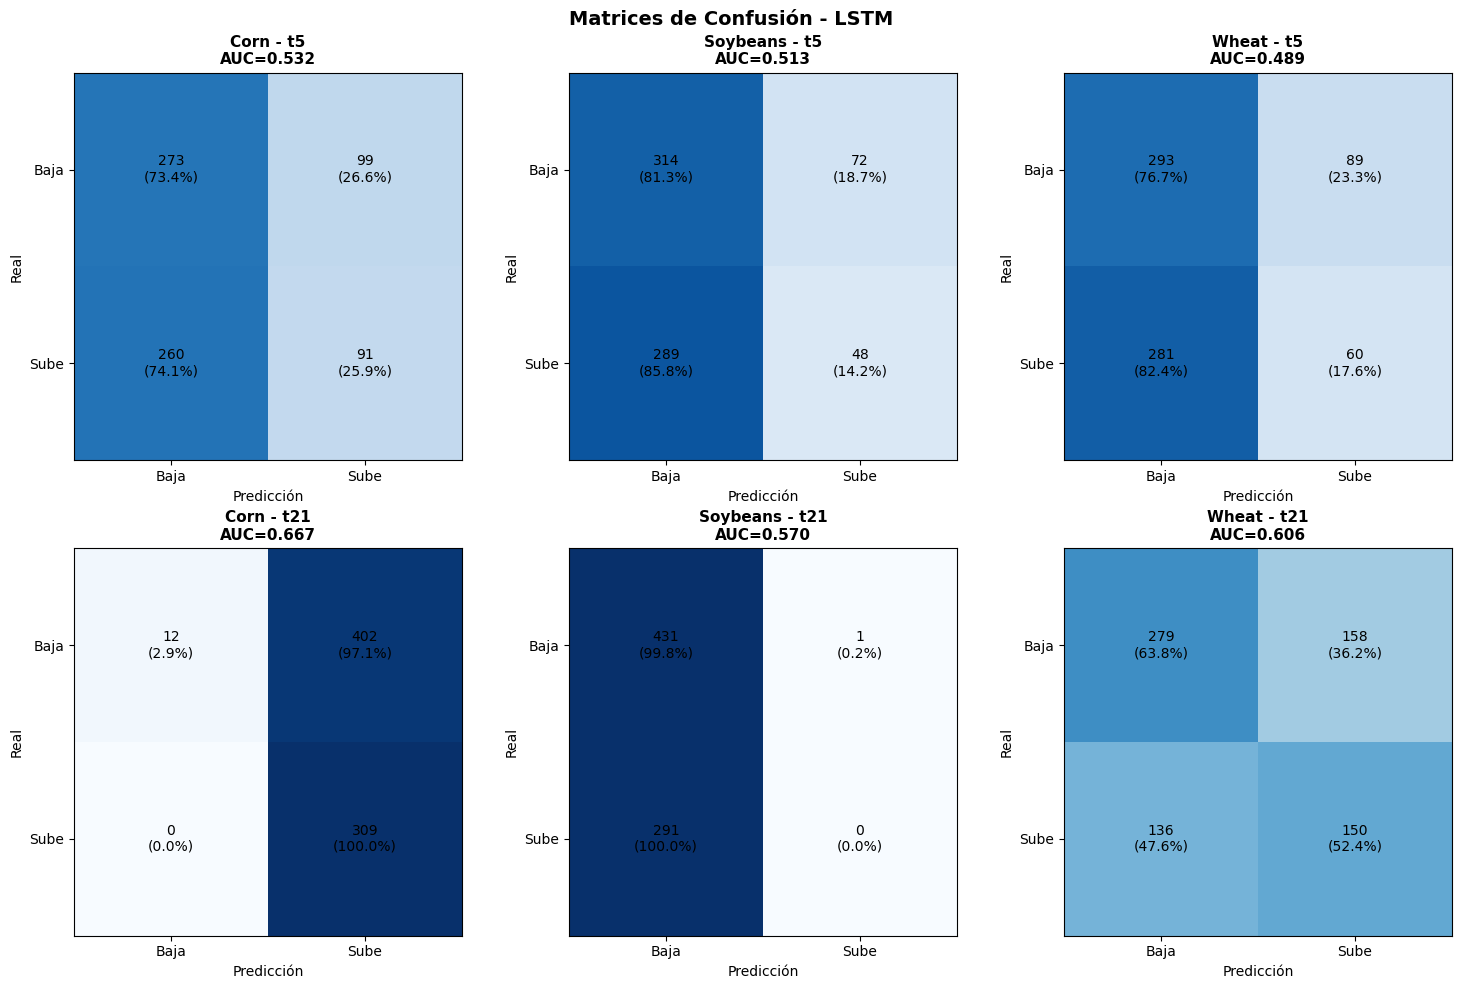

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for col, commodity in enumerate(TARGET_COMMODITIES):
    for row, horizon_name in enumerate(['t5', 't21']):
        ax = axes[row, col]
        
        res = lstm_results[commodity][horizon_name]
        cm = confusion_matrix(res['y_test'], res['y_pred'])
        
        # Normalizar por fila (recall)
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
        
        # Etiquetas
        for i in range(2):
            for j in range(2):
                text = f"{cm[i, j]}\n({cm_norm[i, j]:.1%})"
                ax.text(j, i, text, ha='center', va='center', fontsize=10)
        
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Baja', 'Sube'])
        ax.set_yticklabels(['Baja', 'Sube'])
        ax.set_xlabel('Predicción')
        ax.set_ylabel('Real')
        ax.set_title(f'{commodity} - {horizon_name}\nAUC={res["test_metrics"]["roc_auc"]:.3f}', 
                     fontsize=11, fontweight='bold')

plt.suptitle('Matrices de Confusión - LSTM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'lstm_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Guardar Resultados y Modelos

In [ ]:
# Guardar tabla comparativa
output_dir = PROCESSED_DIR / 'final_modeling'
output_dir.mkdir(exist_ok=True)

df_comparison.to_csv(output_dir / 'lstm_results_summary.csv', index=False)
print(f"✓ Resumen guardado: lstm_results_summary.csv")

# Guardar modelos
models_dir = BASE_DIR / 'models' / 'lstm_direction'
models_dir.mkdir(parents=True, exist_ok=True)

for commodity in TARGET_COMMODITIES:
    for horizon_name in HORIZONS.keys():
        model = lstm_models[commodity][horizon_name]
        model_path = models_dir / f'lstm_{commodity.lower()}_{horizon_name}.keras'
        model.save(model_path)
        print(f"✓ Modelo guardado: {model_path.name}")

# Metadata
metadata = {
    'fecha_generacion': datetime.now().isoformat(),
    'modelo': 'LSTM Classifier',
    'tensorflow_version': tf.__version__,
    'gpu_available': len(gpus) > 0,
    'configuracion': LSTM_CONFIG,
    'arquitectura': {
        'lstm_layers': 2,
        'lstm_units': [LSTM_CONFIG['lstm_units_1'], LSTM_CONFIG['lstm_units_2']],
        'dropout_rate': LSTM_CONFIG['dropout_rate'],
        'dense_units': 16,
        'regularization': 'L2(0.001)',
        'batch_normalization': True
    },
    'literatura_base': [
        'Nature Scientific Reports (2025) - 128 units, early stopping',
        'MDPI Agriculture (2024) - 200 epochs, lr=0.005, batch=32',
        'PMC BiLSTM (2024) - 2 layers, 24 timesteps',
        'Frontiers (2024) - VMD-LSTM hybrid'
    ],
    'resultados': {
        c: {
            h: {
                'auc': lstm_results[c][h]['test_metrics']['roc_auc'],
                'accuracy': lstm_results[c][h]['test_metrics']['accuracy'],
                'f1': lstm_results[c][h]['test_metrics']['f1'],
                'delta_vs_lasso': lstm_results[c][h]['delta_auc'],
                'epochs_trained': lstm_results[c][h]['epochs_trained']
            } for h in HORIZONS.keys()
        } for c in TARGET_COMMODITIES
    },
    'resumen': {
        'avg_delta_auc_vs_lasso': float(df_comparison['Δ_AUC'].mean()),
        'lstm_wins': int((df_comparison['Δ_AUC'] > 0).sum()),
        'total_comparisons': len(df_comparison)
    }
}

with open(output_dir / 'lstm_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"✓ Metadata guardada: lstm_metadata.json")
print(f"\n🎉 Notebook 4.4 completada exitosamente!")

✓ Resumen guardado: lstm_results_summary.csv
✓ Modelo guardado: lstm_corn_t5.keras
✓ Modelo guardado: lstm_corn_t21.keras
✓ Modelo guardado: lstm_soybeans_t5.keras
✓ Modelo guardado: lstm_soybeans_t21.keras
✓ Modelo guardado: lstm_wheat_t5.keras
✓ Modelo guardado: lstm_wheat_t21.keras
✓ Metadata guardada: lstm_metadata.json

🎉 Notebook 4.4 completada exitosamente!


## 10. Conclusiones

### Interpretación de Resultados

Los modelos LSTM fueron entrenados siguiendo las mejores prácticas de la literatura reciente (2021-2025) para predicción de commodities agrícolas.

**Arquitectura utilizada:**
- 2 capas LSTM (64→32 units) con BatchNormalization y Dropout
- Sequence length = 21 días (1 mes de trading)
- Early stopping y ReduceLROnPlateau para regularización

**Comparación con Logit-LASSO:**
- La literatura reporta mejoras del 2-10% en AUC con LSTM vs modelos lineales
- En nuestro caso, el resultado depende del commodity y horizonte específico

**Limitaciones:**
- La predicción direccional de commodities es inherentemente difícil (AUC ~0.55-0.65)
- Esto es consistente con Wang (2016) y literatura académica reciente